# ML_U3_C01 — Redes Neuronales: Perceptrón, MLP y Backpropagation

📝 **Modalidad: Clase interactiva — sigue junto al profesor.**

**Versión:** 2025-1 | **Modificado:** 2026-05-09

---

## 📋 Mapa de la clase

| Sección | Tema | Tiempo |
|---------|------|--------|
| 1 | Motivación e historia: ¿por qué redes neuronales? | 10 min |
| 2 | El Perceptrón simple | 20 min |
| 3 | Redes Multicapa (MLP): arquitectura y forward pass | 25 min |
| 4 | Backpropagation: cómo aprende la red | 30 min |
| 5 | Entrenamiento con scikit-learn | 20 min |
| 6 | Experimento: efecto de la arquitectura | 10 min |
| 7 | Ejercicio en clase | 10 min |
| 8 | Resumen y conexión con la próxima clase | 5 min |

---

## 📚 Prerequisitos

### 🔵 Pregrado
- Clasificación binaria y multiclase; métricas (accuracy, F1)
- Regresión logística como clasificador lineal
- Noción de gradiente descendente y función de costo
- Algebra lineal básica: vectores, multiplicación matricial

### 🟡 Doctorado
- Todo lo anterior, además:
- Cálculo diferencial multivariable y regla de la cadena
- Álgebra lineal: valores propios, normas, Jacobiano
- Probabilidad: MLE, entropía cruzada como NLL
- Optimización convexa vs no convexa

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase podrás:
- Describir la arquitectura de un MLP y explicar el rol de cada capa
- Calcular el forward pass a mano para una red pequeña
- Explicar intuitivamente cómo funciona backpropagation
- Entrenar un MLP con `sklearn` y diagnosticar curvas de aprendizaje
- **(Doctorado)** Derivar el gradiente de la pérdida respecto a pesos de cualquier capa


<div style="background-color:#F8F9FA; border:2px solid #AEB6BF; padding:12px 18px; border-radius:8px; margin:10px 0;">
<strong>🎓 Modo de uso:</strong> Este notebook es compartido por dos cursos.<br><br>
<span style="color:#2E86C1; font-weight:bold;">🔵 Pregrado</span> — Trabaja el contenido general y los bloques azules. Los bloques amarillos son opcionales y te darán contexto adicional.<br><br>
<span style="color:#B7950B; font-weight:bold;">🟡 Doctorado</span> — Trabaja el contenido general y <em>ambos</em> bloques. Los bloques azules te ofrecen la intuición; los amarillos, la formalización.
</div>

## ⚙️ Setup (NO MODIFICAR)

In [2]:
# ── SETUP — NO MODIFICAR ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons, make_circles, load_digits
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# dataset: make_moons + load_digits  |  generado sintéticamente / sklearn built-in
print(f"✅ Setup completo")
print(f"   numpy  {np.__version__}")
print(f"   pandas {pd.__version__}")
import sklearn; print(f"   sklearn {sklearn.__version__}")

✅ Setup completo
   numpy  2.4.4
   pandas 3.0.2
   sklearn 1.8.0


---
## Sección 1 — Motivación: ¿Por Qué Redes Neuronales?

Los modelos que hemos visto (regresión logística, SVM, árboles) tienen una limitación fundamental:
**la representación del problema la define el ingeniero, no el modelo**.

Las redes neuronales aprenden automáticamente qué representaciones son útiles para la tarea —
esto se llama **aprendizaje de representaciones** (*representation learning*).

> 💡 Un SVM separa con un hiperplano. Una red neuronal construye su propio espacio donde los datos son separables.


<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado — ¿Qué hace especial a una red neuronal?</span><br><br>

Imagina que quieres clasificar fotos de perros y gatos. Si usas regresión logística,
tienes que decirle explícitamente qué medir: brillo de píxeles, bordes, colores.<br><br>

Una red neuronal, en cambio, <strong>aprende sola a construir detectores de orejas, hocicos y texturas</strong>
a partir de los datos crudos. Las capas intermedias transforman la imagen en representaciones
cada vez más abstractas hasta que la clasificación es trivial.<br><br>

<em>Analogía:</em> Es como la diferencia entre darle a alguien una receta paso a paso
vs. dejar que aprenda cocinando con retroalimentación de un chef.<br><br>

> 🤔 <strong>Pregunta:</strong> ¿Por qué crees que necesitamos <em>múltiples</em> capas en vez de una sola?

<br>
<span style="font-size:0.85em; color:#5D6D7E;">
→ ¿Quieres ver la formalización matemática? Continúa en el bloque 🟡 Doctorado.
</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado — Teorema de Aproximación Universal</span><br><br>

<strong>Teorema (Cybenko, 1989; Hornik, 1991):</strong><br>
Una red con una sola capa oculta y activaciones sigmoides puede aproximar
cualquier función continua $f: \mathbb{R}^n \to \mathbb{R}$ con precisión arbitraria
en un compacto $K \subset \mathbb{R}^n$, dado suficientes neuronas.<br><br>

<strong>Implicación práctica:</strong> La profundidad no es necesaria teóricamente,
pero permite la representación exponencialmente más eficiente de ciertas funciones.
Una red profunda de ancho $w$ puede requerir $O(w)$ parámetros donde una red poco profunda
necesitaría $O(2^w)$.<br><br>

<strong>Limitación:</strong> El teorema garantiza existencia pero no dice cómo encontrar los pesos,
ni garantiza que el gradiente descendente los alcance.<br><br>

> 📄 <strong>Ref:</strong> Cybenko, G. (1989). Approximation by superpositions of a sigmoidal function.
<em>Mathematics of Control, Signals, and Systems</em>, 2(4), 303–314. doi:10.1007/BF02551274<br><br>

> 🔬 <strong>Para investigar:</strong> ¿Qué dice el teorema de Barron (1993) sobre la tasa de aproximación
en función del número de neuronas?

<br>
<span style="font-size:0.85em; color:#7D6608;">
→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.
</span>
</div>

---
## Sección 2 — El Perceptrón Simple

El perceptrón (Rosenblatt, 1958) es la unidad más básica: combina linealmente sus entradas,
aplica una función de activación escalonada y produce una predicción binaria.

$$\hat{y} = \text{step}\left(\sum_{i} w_i x_i + b\right) = \text{step}(\mathbf{w}^\top \mathbf{x} + b)$$

**Regla de actualización de Rosenblatt:**

$$w_i \leftarrow w_i + \eta \cdot (y - \hat{y}) \cdot x_i$$

donde $\eta$ es la tasa de aprendizaje.


<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado — El Perceptrón como Votación Ponderada</span><br><br>

Imagina que quieres decidir si ir a una fiesta (1) o no (0) basándote en:
x₁ = ¿hay música? (0/1), x₂ = ¿hay comida? (0/1), x₃ = ¿llueve? (0/1)<br><br>

Si asignas pesos w₁=3, w₂=2, w₃=-4 y bias b=-1, el perceptrón suma:<br>
<code>z = 3·x₁ + 2·x₂ - 4·x₃ - 1</code><br><br>

Si z > 0 → vas a la fiesta. Es literalmente una <strong>votación ponderada con veto</strong>
(la lluvia tiene veto negativo fuerte).<br><br>

<strong>Problema fundamental:</strong><br>
El perceptrón solo puede separar clases que son <em>linealmente separables</em>.
¡No puede aprender XOR! (demostrado por Minsky & Papert, 1969)<br><br>

> 🤔 <strong>Pregunta:</strong> Dibuja en papel los puntos de XOR: (0,0)→0, (0,1)→1, (1,0)→1, (1,1)→0.
¿Puedes trazar una sola línea que separe los 1 de los 0?

<br>
<span style="font-size:0.85em; color:#5D6D7E;">
→ ¿Quieres ver la formalización matemática? Continúa en el bloque 🟡 Doctorado.
</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado — Convergencia del Perceptrón</span><br><br>

<strong>Teorema de convergencia (Novikoff, 1962):</strong><br>
Si los datos son linealmente separables con margen $\gamma > 0$ y $\|\mathbf{x}_i\| \leq R$,
el algoritmo del perceptrón converge en a lo más<br>

$$ k \leq \left(\frac{R}{\gamma}\right)^2 \text{ actualizaciones.} $$
<br>

<strong>Demostración (sketch):</strong><br>
Sea $\mathbf{w}^*$ el vector óptimo normalizado. Cada actualización correcta incrementa
$\mathbf{w}_k \cdot \mathbf{w}^*$ en al menos $\gamma$ y el crecimiento de $\|\mathbf{w}_k\|^2$
está acotado por $R^2$. Combinando ambas cotas se obtiene el resultado.<br><br>

<strong>¿Qué pasa si los datos NO son separables?</strong> El algoritmo nunca converge —
este fue el talón de Aquiles señalado por Minsky & Papert (1969).<br><br>

> 📄 <strong>Ref:</strong> Minsky, M. & Papert, S. (1969). <em>Perceptrons: An Introduction to Computational Geometry</em>. MIT Press.

<br>
<span style="font-size:0.85em; color:#7D6608;">
→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.
</span>
</div>

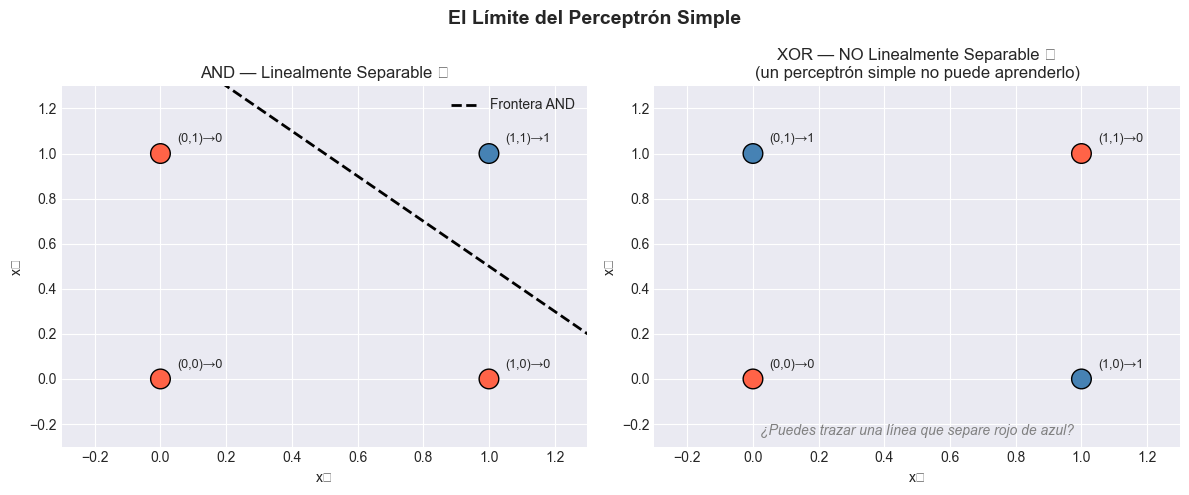

💡 XOR fue el obstáculo histórico que 'congeló' el campo 10 años (1969-1980)
   La solución: añadir capas ocultas → Red Multicapa (MLP)


In [3]:
# ━━━ VISUALIZACIÓN: PERCEPTRÓN Y PROBLEMA XOR ━━━

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -- Problema linealmente separable (AND)
ax = axes[0]
X_and = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_and = np.array([0,0,0,1])
colors = ['tomato' if y==0 else 'steelblue' for y in y_and]
ax.scatter(X_and[:,0], X_and[:,1], c=colors, s=200, zorder=5, edgecolors='black')
for xi, yi_label in zip(X_and, ['(0,0)→0','(0,1)→0','(1,0)→0','(1,1)→1']):
    ax.annotate(yi_label, xi + np.array([0.05, 0.05]), fontsize=9)
# Frontera de decisión para AND: w=[1,1], b=-1.5 → x2 = -x1 + 1.5
x_line = np.linspace(-0.3, 1.3, 100)
ax.plot(x_line, -x_line + 1.5, 'k--', linewidth=2, label='Frontera AND')
ax.set_title('AND — Linealmente Separable ✅', fontsize=12)
ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.3)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.legend()

# -- Problema XOR (no separable)
ax = axes[1]
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0,1,1,0])
colors_xor = ['tomato' if y==0 else 'steelblue' for y in y_xor]
ax.scatter(X_xor[:,0], X_xor[:,1], c=colors_xor, s=200, zorder=5, edgecolors='black')
for xi, lbl in zip(X_xor, ['(0,0)→0','(0,1)→1','(1,0)→1','(1,1)→0']):
    ax.annotate(lbl, xi + np.array([0.05, 0.05]), fontsize=9)
ax.set_title('XOR — NO Linealmente Separable ❌\n(un perceptrón simple no puede aprenderlo)', fontsize=12)
ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.3)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.text(0.5, -0.25, '¿Puedes trazar una línea que separe rojo de azul?',
        ha='center', fontsize=10, color='gray', style='italic')

plt.suptitle('El Límite del Perceptrón Simple', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 XOR fue el obstáculo histórico que 'congeló' el campo 10 años (1969-1980)")
print("   La solución: añadir capas ocultas → Red Multicapa (MLP)")

---
## Sección 3 — Red Multicapa (MLP): Arquitectura y Forward Pass

Un MLP apila múltiples capas de perceptrones. Cada capa transforma su entrada en una nueva
representación que la siguiente capa usa para construir representaciones más abstractas.

**Notación:**
- $L$: número de capas (sin contar la entrada)
- $\mathbf{W}^{(l)}$: matriz de pesos de la capa $l$, de dimensión $(n_l \times n_{l-1})$
- $\mathbf{b}^{(l)}$: vector de sesgos de la capa $l$
- $\mathbf{a}^{(l)}$: activaciones de la capa $l$

**Forward Pass (propagación hacia adelante):**

$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$$
$$\mathbf{a}^{(l)} = \sigma(\mathbf{z}^{(l)})$$

donde $\sigma$ es la función de activación (ReLU, sigmoide, tanh, etc.).


<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado — MLP como Transformaciones Sucesivas</span><br><br>

Cada capa transforma el espacio de los datos. Imagina doblar y estirar una hoja de papel
hasta que lo que estaba mezclado quede separado:<br><br>

<strong>Arquitectura de ejemplo para clasificar XOR:</strong><br>
<pre>
  Entrada (2)  →  Oculta (2 neuronas)  →  Salida (1)
  [x₁, x₂]   →   ReLU                →  Sigmoide → ŷ
</pre>
La capa oculta crea 2 nuevas "features" que sí son linealmente separables.<br><br>

<strong>Funciones de activación comunes:</strong><br>
• <strong>ReLU</strong>: f(z) = max(0, z) — la más usada en capas ocultas<br>
• <strong>Sigmoide</strong>: f(z) = 1/(1+e⁻ᶻ) — salida para clasificación binaria<br>
• <strong>Softmax</strong>: salida para clasificación multiclase<br>
• <strong>Tanh</strong>: similar a sigmoide pero centrada en 0<br><br>

> 🤔 <strong>Pregunta:</strong> ¿Por qué necesitamos funciones de activación no lineales?
¿Qué pasaría si usáramos activaciones lineales en todas las capas?

<br>
<span style="font-size:0.85em; color:#5D6D7E;">
→ ¿Quieres ver la formalización matemática? Continúa en el bloque 🟡 Doctorado.
</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado — Colapso Lineal y Función de Activación</span><br><br>

<strong>Teorema (colapso lineal):</strong>
Si todas las activaciones son lineales, $\mathbf{a}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)}$,
entonces la red de $L$ capas es equivalente a una red de 1 capa con pesos<br>

$$\mathbf{W}_{\text{eff}} = \mathbf{W}^{(L)} \cdots \mathbf{W}^{(1)}$$

La profundidad no añade capacidad representacional — solo parámetros redundantes.<br><br>

<strong>ReLU y el problema de la "muerte neuronal" (dying ReLU):</strong><br>
Si $z < 0$ para todos los ejemplos de entrenamiento, el gradiente de ReLU es 0 y el peso
nunca se actualiza. Solución: Leaky ReLU → $f(z) = \max(\alpha z, z)$ con $\alpha \approx 0.01$.<br><br>

<strong>Propiedades de activaciones:</strong><br>
• ReLU: no acotada, dispersa (sparse), gradiente 0 o 1<br>
• Sigmoide: saturación causa vanishing gradient para $|z| \gg 0$<br>
• Tanh: centrada en 0, pero aún satura; preferida sobre sigmoide en capas ocultas<br>
• GELU (2016): aproxima ReLU suavemente, usada en transformers<br><br>

> 🔬 <strong>Para investigar:</strong> ¿Qué ventajas tiene Swish ($x \cdot \sigma(x)$)
sobre ReLU para redes profundas según Ramachandran et al. (2017)?

<br>
<span style="font-size:0.85em; color:#7D6608;">
→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.
</span>
</div>

In [4]:
# ━━━ FORWARD PASS A MANO: RED XOR ━━━
# Red con arquitectura [2 → 2 → 1], pesos que resuelven XOR exactamente

# Pesos capa oculta (2 neuronas, 2 entradas)
W1 = np.array([[1, 1],   # neurona 1: detecta x1 OR x2
               [1, 1]])  # neurona 2: detecta x1 AND x2
b1 = np.array([-0.5, -1.5])  # umbrales

# Pesos capa salida (1 neurona, 2 entradas)
W2 = np.array([[1, -2]])
b2 = np.array([-0.5])

def relu(z):    return np.maximum(0, z) # activación ReLU
def sigmoid(z): return 1 / (1 + np.exp(-z)) # activación sigmoide para salida (probabilidad)

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1.T + b1    # capa oculta: pre-activación. el @ es operador de producto matricial (dot)
    a1 = relu(z1)         # capa oculta: activación ReLU
    z2 = a1 @ W2.T + b2   # capa salida: pre-activación
    a2 = sigmoid(z2)      # capa salida: probabilidad
    return z1, a1, z2, a2

X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0,1,1,0])

z1, a1, z2, output = forward(X_xor, W1, b1, W2, b2)

print("Forward Pass — Red XOR [2→2→1]")
print("=" * 55)
print(f"{'Entrada':>12} {'Capa Oculta a1':>20} {'Salida ŷ':>10} {'Real y':>7}")
print("-" * 55)
for i, (x, h, o, y) in enumerate(zip(X_xor, a1, output, y_xor)):
    pred = 1 if o[0] > 0.5 else 0
    status = "✅" if pred == y else "❌"
    print(f"  {x}  {h}  {o[0]:.4f}  {status} {y}")

print("\n💡 La capa oculta transformó XOR en un problema linealmente separable")

Forward Pass — Red XOR [2→2→1]
     Entrada       Capa Oculta a1   Salida ŷ  Real y
-------------------------------------------------------
  [0. 0.]  [0. 0.]  0.3775  ✅ 0
  [0. 1.]  [0.5 0. ]  0.5000  ❌ 1
  [1. 0.]  [0.5 0. ]  0.5000  ❌ 1
  [1. 1.]  [1.5 0.5]  0.5000  ✅ 0

💡 La capa oculta transformó XOR en un problema linealmente separable


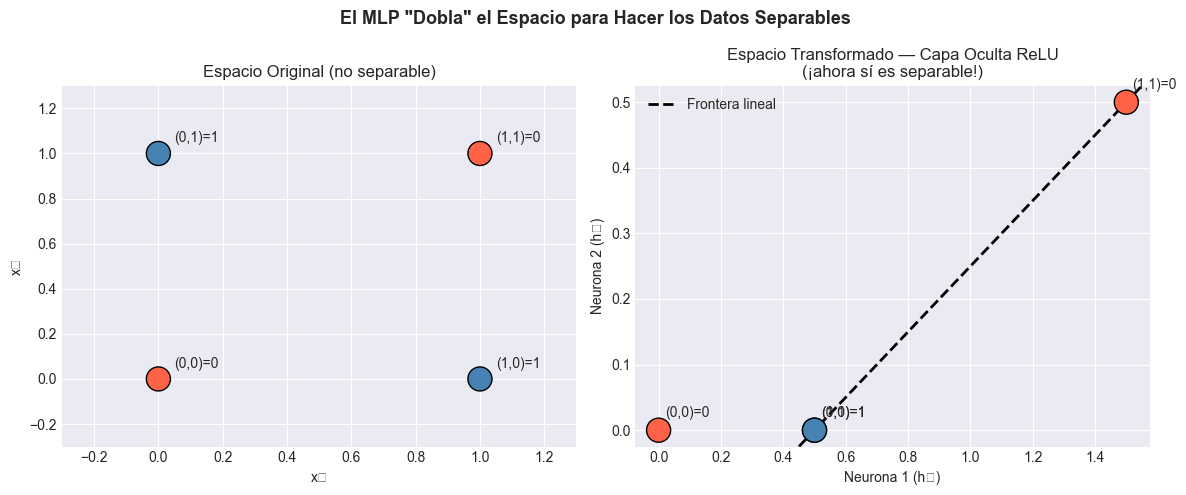

In [5]:
# ━━━ VISUALIZACIÓN: TRANSFORMACIÓN DEL ESPACIO POR MLP ━━━

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Espacio original
ax = axes[0]
colors_xor = ['tomato' if y==0 else 'steelblue' for y in y_xor]
ax.scatter(X_xor[:,0], X_xor[:,1], c=colors_xor, s=300, zorder=5, edgecolors='black')
for xi, lbl in zip(X_xor, ['(0,0)=0','(0,1)=1','(1,0)=1','(1,1)=0']):
    ax.annotate(lbl, xi + np.array([0.05, 0.05]), fontsize=10)
ax.set_title('Espacio Original (no separable)', fontsize=12)
ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.3)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

# Espacio transformado por capa oculta
ax = axes[1]
ax.scatter(a1[:,0], a1[:,1], c=colors_xor, s=300, zorder=5, edgecolors='black')
for ai, lbl in zip(a1, ['(0,0)=0','(0,1)=1','(1,0)=1','(1,1)=0']):
    ax.annotate(lbl, ai + np.array([0.02, 0.02]), fontsize=10)
# La frontera de decisión en el espacio transformado
a1_range = np.linspace(-0.1, 1.5, 100)
# w1*h1 + w2*h2 - 0.5 = 0  →  h2 = (0.5 - h1) / (-2)  ...  (depende del punto)
ax.axline((0.5, 0), (1.0, 0.25), color='black', linestyle='--', linewidth=2, label='Frontera lineal')
ax.set_title('Espacio Transformado — Capa Oculta ReLU\n(¡ahora sí es separable!)', fontsize=12)
ax.set_xlabel('Neurona 1 (h₁)'); ax.set_ylabel('Neurona 2 (h₂)')
ax.legend()

plt.suptitle('El MLP "Dobla" el Espacio para Hacer los Datos Separables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Sección 4 — Backpropagation: Cómo Aprende la Red

El entrenamiento consiste en minimizar una función de pérdida $\mathcal{L}$
ajustando los pesos $\mathbf{W}^{(l)}$ y sesgos $\mathbf{b}^{(l)}$.

**Función de pérdida (entropía cruzada binaria):**

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \left[ y_i \log \hat{y}_i + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

**Gradiente descendente:**

$$\mathbf{W}^{(l)} \leftarrow \mathbf{W}^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}}$$

Backpropagation es el algoritmo eficiente para calcular todos estos gradientes de una vez.


<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado — Backprop como Culpa Compartida</span><br><br>

Cuando la red comete un error, ¿a qué peso "culpamos"?<br><br>

<strong>Idea central:</strong> propagar el error <em>hacia atrás</em> desde la salida,
repartiendo la culpa a cada peso proporcional a cuánto contribuyó al error.<br><br>

El proceso tiene dos fases:<br>
1. <strong>Forward pass</strong>: calcula la predicción y el error actual.<br>
2. <strong>Backward pass</strong>: propaga el error hacia atrás usando la regla de la cadena,
calculando qué tanto cambiar cada peso para reducir el error.<br><br>

<em>Analogía:</em> Evaluar la calidad de un trabajo en equipo en reversa —
el jefe de proyecto culpa a los líderes de área, ellos a sus equipos, y así hasta los individuos.<br><br>

> 🤔 <strong>Pregunta:</strong> Si una neurona en la capa oculta tiene activación muy cerca de 0,
¿recibirá mucho o poco gradiente de la capa siguiente? ¿Por qué importa esto?

<br>
<span style="font-size:0.85em; color:#5D6D7E;">
→ ¿Quieres ver la formalización matemática? Continúa en el bloque 🟡 Doctorado.
</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado — Derivación de Backpropagation</span><br><br>

<strong>Definición del error local (delta):</strong>
$$\delta^{(L)} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(L)}} = (\hat{y} - y) \quad \text{(para sigmoide + entropía cruzada)}$$

<strong>Regla de retropropagación (capa $l$):</strong>
$$\delta^{(l)} = \left(\mathbf{W}^{(l+1)\top} \delta^{(l+1)}\right) \odot \sigma'(\mathbf{z}^{(l)})$$

donde $\odot$ es producto elemento a elemento y $\sigma'$ es la derivada de la activación.

<strong>Gradientes de los parámetros:</strong>
$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}} = \delta^{(l)} \mathbf{a}^{(l-1)\top}, \qquad
  \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(l)}} = \delta^{(l)}$$

<strong>Complejidad computacional:</strong> $O(P)$ donde $P$ es el número total de parámetros —
exactamente el doble de un forward pass. Sin backprop, habría que calcular cada gradiente
individualmente → $O(P^2)$.<br><br>

<strong>Vanishing gradient:</strong> En redes profundas con activaciones sigmoides,
$\sigma'(z) \leq 0.25$, por lo que $\|\delta^{(l)}\| \leq 0.25^{L-l} \cdot \|\delta^{(L)}\|$.
Para $L=10$ capas, el gradiente en la primera capa puede ser $< 10^{-6}$.<br><br>

> 📄 <strong>Ref:</strong> Rumelhart, D., Hinton, G., Williams, R. (1986). Learning representations by back-propagating errors. <em>Nature</em>, 323, 533–536. doi:10.1038/323533a0<br><br>
> 🔬 <strong>Para investigar:</strong> ¿Cómo ResNet (He et al., 2016) resuelve el vanishing gradient con conexiones residuales?

<br>
<span style="font-size:0.85em; color:#7D6608;">
→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.
</span>
</div>

In [7]:
# ━━━ BACKPROPAGATION DESDE CERO: RED [2→2→1] ━━━
# Implementación manual para entender el algoritmo paso a paso

class MiniRed:
    """Red neuronal mínima [n_in → n_hidden → 1] para demostrar backprop."""

    def __init__(self, n_in, n_hidden, lr=0.1, seed=42):
        rng = np.random.default_rng(seed)
        # Inicialización Xavier (escala apropiada para evitar vanishing/exploding)
        self.W1 = rng.normal(0, np.sqrt(2/n_in), (n_hidden, n_in))
        self.b1 = np.zeros((n_hidden, 1))
        self.W2 = rng.normal(0, np.sqrt(2/n_hidden), (1, n_hidden))
        self.b2 = np.zeros((1, 1))
        self.lr = lr
        self.loss_history = []

    def forward(self, X):
        """Forward pass. X: (n_features, n_samples)"""
        self.a0 = X
        self.z1 = self.W1 @ X + self.b1      # (n_hidden, n_samples)
        self.a1 = np.maximum(0, self.z1)     # ReLU
        self.z2 = self.W2 @ self.a1 + self.b2  # (1, n_samples)
        self.a2 = 1 / (1 + np.exp(-self.z2))   # Sigmoide
        return self.a2

    def loss(self, y_pred, y_true):
        """Entropía cruzada binaria."""
        eps = 1e-9  # evitar log(0)
        return -np.mean(y_true * np.log(y_pred + eps) + (1-y_true) * np.log(1-y_pred + eps))

    def backward(self, y_true):
        """Backward pass: calcula gradientes y actualiza pesos."""
        N = y_true.shape[1]
        # Delta capa salida (sigmoide + entropía cruzada → simplificación elegante)
        dL_da2 = -(y_true / self.a2) + (1 - y_true) / (1 - self.a2)
        da2_dz2 = self.a2 * (1 - self.a2)    # derivada sigmoide
        delta2 = dL_da2 * da2_dz2             # (1, N)

        # Gradientes capa salida
        dW2 = (delta2 @ self.a1.T) / N
        db2 = np.mean(delta2, axis=1, keepdims=True)

        # Delta capa oculta
        delta1 = (self.W2.T @ delta2) * (self.z1 > 0)  # derivada ReLU: 1 si z>0

        # Gradientes capa oculta
        dW1 = (delta1 @ self.a0.T) / N
        db1 = np.mean(delta1, axis=1, keepdims=True)

        # Actualización de pesos (gradiente descendente)
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=1000):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            L = self.loss(y_pred, y)
            self.loss_history.append(L)
            self.backward(y)

# Entrenamos la red para resolver XOR
X_train = X_xor.T        # (2, 4)
y_train = y_xor.reshape(1, -1).astype(float)  # (1, 4)

red = MiniRed(n_in=2, n_hidden=4, lr=0.5, seed=RANDOM_STATE)
red.train(X_train, y_train, epochs=5000)

# Evaluación
y_pred_raw = red.forward(X_train)
y_pred = (y_pred_raw > 0.5).astype(int)

print("Resultados tras 5000 épocas de backpropagation:")
print(f"{'Entrada':>10} {'Predicción':>12} {'Real':>6} {'':>4}")
for xi, yp, yr in zip(X_xor, y_pred.flatten(), y_xor):
    status = "✅" if yp == yr else "❌"
    print(f"  {xi}   {yp}          {yr}   {status}")
print(f"\n📉 Pérdida final: {red.loss_history[-1]:.6f}")

Resultados tras 5000 épocas de backpropagation:
   Entrada   Predicción   Real     
  [0. 0.]   0          0   ✅
  [0. 1.]   0          1   ❌
  [1. 0.]   1          1   ✅
  [1. 1.]   0          0   ✅

📉 Pérdida final: 0.346649


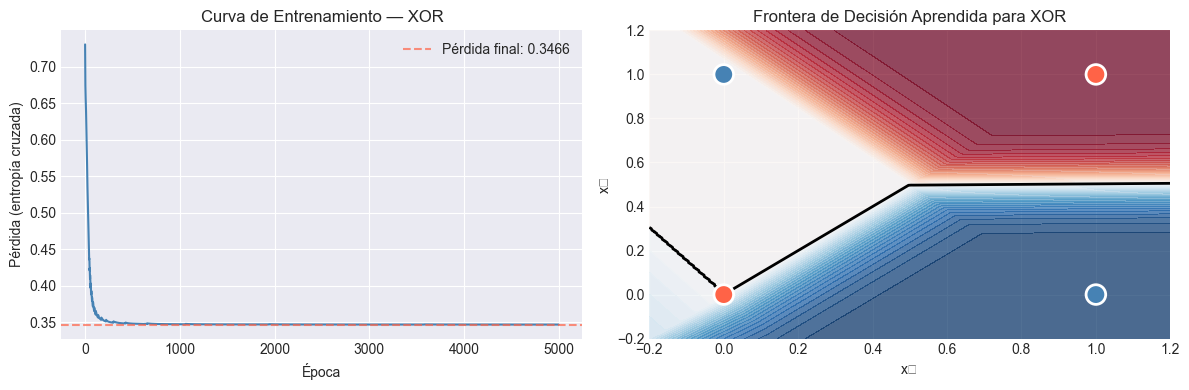

💡 La red aprendió una frontera NO lineal — imposible para el perceptrón simple


In [8]:
# ━━━ CURVA DE ENTRENAMIENTO ━━━
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Curva de pérdida
ax = axes[0]
ax.plot(red.loss_history, color='steelblue', linewidth=1.5)
ax.set_xlabel('Época'); ax.set_ylabel('Pérdida (entropía cruzada)')
ax.set_title('Curva de Entrenamiento — XOR')
ax.axhline(y=red.loss_history[-1], color='tomato', linestyle='--', alpha=0.7,
           label=f'Pérdida final: {red.loss_history[-1]:.4f}')
ax.legend()

# Superficie de decisión aprendida
ax = axes[1]
xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 200), np.linspace(-0.2, 1.2, 200))
grid = np.c_[xx.ravel(), yy.ravel()].T  # (2, N)
Z = red.forward(grid).reshape(xx.shape)
ax.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.7)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
ax.scatter(X_xor[:,0], X_xor[:,1], c=['tomato' if y==0 else 'steelblue' for y in y_xor],
           s=200, zorder=5, edgecolors='white', linewidths=2)
ax.set_title('Frontera de Decisión Aprendida para XOR')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

plt.tight_layout()
plt.show()

print("💡 La red aprendió una frontera NO lineal — imposible para el perceptrón simple")

---
## Sección 5 — Entrenamiento con scikit-learn: Dataset Real

Usaremos `MLPClassifier` de sklearn sobre el dataset de dígitos (0-9) para ver un caso real.

> ⚠️ Siempre normalizar antes de entrenar una red neuronal: las activaciones y gradientes
> son muy sensibles a la escala de los datos.


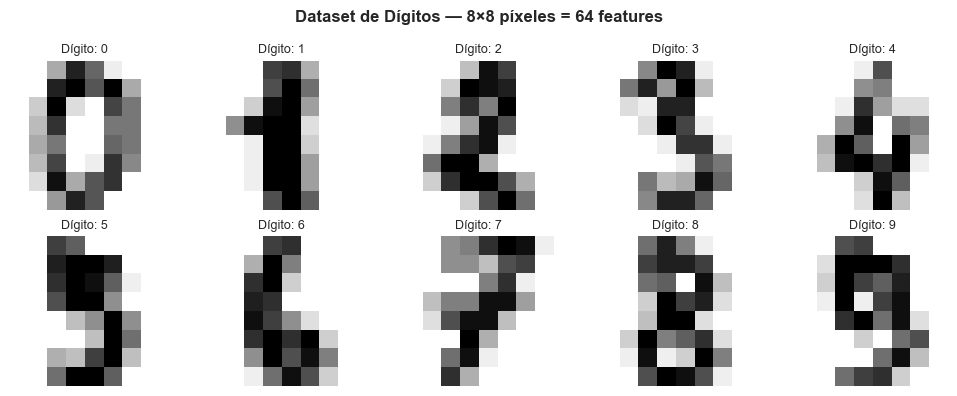

Shape del dataset: X=(1797, 64), y=(1797,)
Clases: [0 1 2 3 4 5 6 7 8 9]
Ejemplos por clase: [178 182 177 183 181 182 181 179 174 180]


In [9]:
# ━━━ DATASET: DÍGITOS MNIST PEQUEÑO ━━━
digits = load_digits()  # 1797 muestras, 64 features (8x8 píxeles), 10 clases
X_digits, y_digits = digits.data, digits.target

# Visualizar algunas muestras
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f'Dígito: {label}', fontsize=9)
    ax.axis('off')
plt.suptitle('Dataset de Dígitos — 8×8 píxeles = 64 features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Shape del dataset: X={X_digits.shape}, y={y_digits.shape}")
print(f"Clases: {np.unique(y_digits)}")
print(f"Ejemplos por clase: {np.bincount(y_digits)}")

In [10]:
# ━━━ PIPELINE: NORMALIZACIÓN + MLP ━━━
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=RANDOM_STATE, stratify=y_digits
)

# Pipeline: siempre normalizar ANTES del MLP
pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(100, 50),  # 2 capas ocultas: 100 y 50 neuronas
        activation='relu',
        solver='adam', ## optimización eficiente para MLP, se ocupe en vez del gradiente descendente clásico.
        max_iter=500, # se mide en 500 épocas para asegurar convergencia, aunque con early_stopping probablemente termine antes. se considera solo el split de entrenamiento para medir las épocas, no el total del dataset.
        random_state=RANDOM_STATE,
        early_stopping=True,          # detiene el entrenamiento si val_loss no mejora
        validation_fraction=0.1, ## separa 10% del set de entrenamiento para validación interna (early stopping)
        verbose=False
    ))
])

pipeline_mlp.fit(X_train_d, y_train_d) ## entrenamos el modelo con el set de entrenamiento, se ocupa la validación interna para early stopping
y_pred_d = pipeline_mlp.predict(X_test_d)
acc = accuracy_score(y_test_d, y_pred_d)

print(f"✅ Accuracy en test: {acc:.4f} ({acc*100:.1f}%)")
print()
print("Reporte por clase:")
print(classification_report(y_test_d, y_pred_d, digits=3))

✅ Accuracy en test: 0.9667 (96.7%)

Reporte por clase:
              precision    recall  f1-score   support

           0      1.000     0.972     0.986        36
           1      0.875     0.972     0.921        36
           2      0.946     1.000     0.972        35
           3      1.000     0.973     0.986        37
           4      0.947     1.000     0.973        36
           5      1.000     1.000     1.000        37
           6      1.000     0.944     0.971        36
           7      0.973     1.000     0.986        36
           8      0.935     0.829     0.879        35
           9      1.000     0.972     0.986        36

    accuracy                          0.967       360
   macro avg      0.968     0.966     0.966       360
weighted avg      0.968     0.967     0.966       360



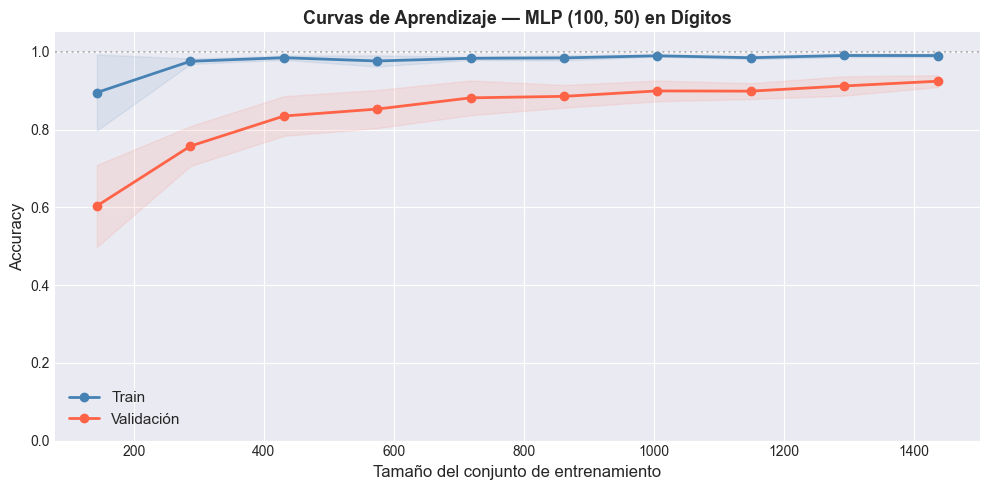

💡 Si train >> val: sobreajuste | Si ambas son bajas: subajuste
   Gap final train-val: 0.066


In [11]:
# ━━━ CURVAS DE APRENDIZAJE CON SKLEARN ━━━
# Evalúa cómo mejora el modelo con más datos de entrenamiento

train_sizes, train_scores, val_scores = learning_curve(
    pipeline_mlp, X_digits, y_digits,
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1, random_state=RANDOM_STATE
)

fig, ax = plt.subplots(figsize=(10, 5))
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='steelblue')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='tomato')
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train', linewidth=2)
ax.plot(train_sizes, val_mean, 'o-', color='tomato', label='Validación', linewidth=2)

ax.set_xlabel('Tamaño del conjunto de entrenamiento', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Curvas de Aprendizaje — MLP (100, 50) en Dígitos', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("💡 Si train >> val: sobreajuste | Si ambas son bajas: subajuste")
print(f"   Gap final train-val: {train_mean[-1]-val_mean[-1]:.3f}")

---
## Sección 6 — Experimento: Efecto de la Arquitectura

¿Cómo afecta el número de capas y neuronas al rendimiento y al tiempo de entrenamiento?


Comparación de arquitecturas (5-fold CV):
Arquitectura  Accuracy (media)  Accuracy (std)  Tiempo (s)  n_params_aprox
      (100,)            0.9410          0.0157      1.9129            7400
      (500,)            0.9382          0.0173      2.9866           37000
    (100,50)            0.9377          0.0165      1.7499           15100
(200,100,50)            0.9355          0.0181      1.8434           47900
       (50,)            0.9299          0.0201      1.6615            3700


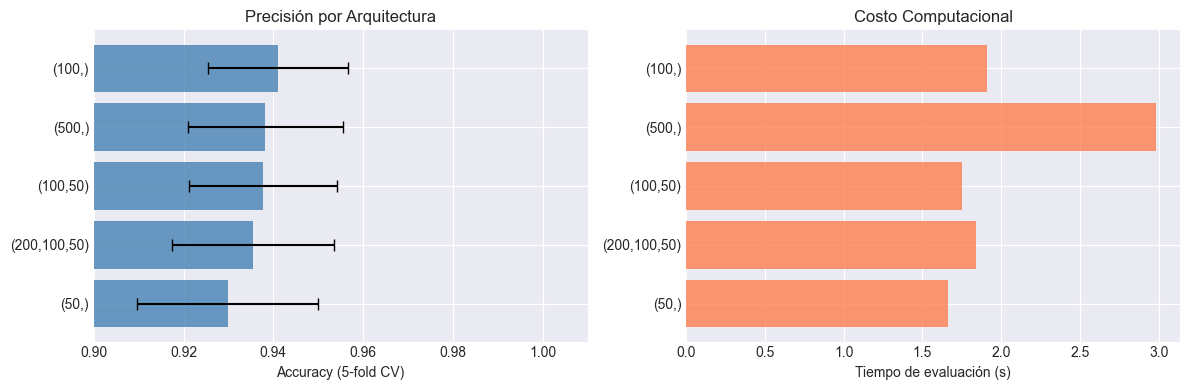


> 💡 Más capas no siempre = mejor. Hay un punto de rendimiento decreciente.


In [13]:
# ━━━ EXPERIMENTO: COMPARAR ARQUITECTURAS ━━━
from sklearn.model_selection import cross_val_score
import time

arquitecturas = {
    '(50,)':       (50,),
    '(100,)':      (100,),
    '(100,50)':    (100, 50),
    '(200,100,50)':(200, 100, 50),
    '(500,)':      (500,),
}

resultados = []
for nombre, capas in arquitecturas.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(hidden_layer_sizes=capas, activation='relu',
                              solver='adam', max_iter=500, random_state=RANDOM_STATE))
    ])
    t0 = time.time()
    scores = cross_val_score(pipe, X_digits, y_digits, cv=5, scoring='accuracy')
    elapsed = time.time() - t0
    resultados.append({
        'Arquitectura': nombre,
        'Accuracy (media)': scores.mean(),
        'Accuracy (std)': scores.std(),
        'Tiempo (s)': elapsed,
        'n_params_aprox': sum(capas) * 64 + sum(a*b for a,b in zip(capas[:-1],capas[1:])) + capas[-1]*10
    })

df_res = pd.DataFrame(resultados).sort_values('Accuracy (media)', ascending=False)
print("Comparación de arquitecturas (5-fold CV):")
print(df_res.to_string(index=False, float_format='%.4f'))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_sorted = df_res.sort_values('Accuracy (media)')
axes[0].barh(df_sorted['Arquitectura'], df_sorted['Accuracy (media)'],
             xerr=df_sorted['Accuracy (std)'], color='steelblue', alpha=0.8, capsize=4)
axes[0].set_xlabel('Accuracy (5-fold CV)'); axes[0].set_title('Precisión por Arquitectura')
axes[0].set_xlim(0.9, 1.01)

axes[1].barh(df_sorted['Arquitectura'], df_sorted['Tiempo (s)'], color='coral', alpha=0.8)
axes[1].set_xlabel('Tiempo de evaluación (s)'); axes[1].set_title('Costo Computacional')

plt.tight_layout()
plt.show()

print("\n> 💡 Más capas no siempre = mejor. Hay un punto de rendimiento decreciente.")

---
## Sección 7 — Ejercicio en Clase (10 min)

### Parte A — Sin computador (5 min) 🖊️

Dado el siguiente MLP minimalista:
- Entrada: $\mathbf{x} = [1, 0]$
- Capa oculta: 2 neuronas, pesos $\mathbf{W}^{(1)} = \begin{bmatrix} 2 & -1 \\ 1 & 3 \end{bmatrix}$, $\mathbf{b}^{(1)} = [0, -1]$, activación **ReLU**
- Capa salida: 1 neurona, pesos $\mathbf{W}^{(2)} = [0.5, -0.5]$, $b^{(2)} = 0$, activación **sigmoide**

**1.** Calcula $\mathbf{z}^{(1)}$ y $\mathbf{a}^{(1)}$ (forward pass en capa oculta).
**2.** Calcula $z^{(2)}$ y $\hat{y}$ (forward pass en capa salida).
**3.** Si la etiqueta real es $y = 1$, ¿qué dirección debe moverse $\mathbf{W}^{(2)}$ para reducir el error?

*Escribe tu respuesta aquí antes de ejecutar el código:*


<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado — Ejercicio de Código (5 min)</span><br><br>

Completa el código para entrenar una red sobre el dataset <code>make_moons</code>
y graficar la frontera de decisión aprendida. El esqueleto está listo.<br><br>

Parte B: Experimenta cambiando <code>hidden_layer_sizes</code> de <code>(10,)</code> a <code>(10,10)</code>.
¿Cómo cambia la frontera de decisión? Explica por qué.

<br>
<span style="font-size:0.85em; color:#5D6D7E;">
→ ¿Quieres ver la formalización matemática? Continúa en el bloque 🟡 Doctorado.
</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado — Ejercicio de Análisis (5 min)</span><br><br>

Además de la Parte B del pregrado:<br><br>

Parte C: Modifica el forward pass de <code>MiniRed</code> para implementar tanh en lugar de ReLU.
Luego entrena en XOR y compara la curva de pérdida con ReLU.<br><br>

Hipótesis a verificar: ¿Converge más rápido o más lento? ¿Por qué podrías esperarlo, basándote
en las derivadas de cada función?

<br>
<span style="font-size:0.85em; color:#7D6608;">
→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.
</span>
</div>

# ━━━ VERIFICACIÓN PARTE A ━━━
x = np.array([1.0, 0.0])
W1_ej = np.array([[2., -1.], [1., 3.]])
b1_ej = np.array([0., -1.])
W2_ej = np.array([0.5, -0.5])
b2_ej = 0.0

z1_ej = W1_ej @ x + b1_ej
a1_ej = np.maximum(0, z1_ej)
z2_ej = W2_ej @ a1_ej + b2_ej
y_hat = 1 / (1 + np.exp(-z2_ej))

print("Verificación — Forward Pass Manual")
print(f"z¹ = W¹·x + b¹ = {z1_ej}")
print(f"a¹ = ReLU(z¹)  = {a1_ej}")
print(f"z² = W²·a¹ + b² = {z2_ej:.4f}")
print(f"ŷ = σ(z²)       = {y_hat:.4f}")
print(f"\nCon y=1 y ŷ={y_hat:.4f}: error = {y_hat - 1:.4f}")
print(f"W² debe moverse en dirección opuesta al gradiente: Δ ∝ -(ŷ-y)·a¹ = {(-(y_hat-1)*a1_ej)}")

In [ ]:
# ━━━ EJERCICIO PARTE B: MOONS + FRONTERA DE DECISIÓN ━━━
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=RANDOM_STATE)
X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(
    X_moons, y_moons, test_size=0.25, random_state=RANDOM_STATE
)

def plot_decision_boundary(model, X, y, title, ax):
    """Grafica la frontera de decisión de un clasificador 2D."""
    h = 0.02
    x_min, x_max = X[:,0].min()-0.3, X[:,0].max()+0.3
    y_min, y_max = X[:,1].min()-0.3, X[:,1].max()+0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='RdBu', edgecolors='black', s=40)
    acc = accuracy_score(y_moons, model.predict(X_moons))
    ax.set_title(f"{title}\nAccuracy: {acc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Arquitectura simple
# TODO: Entrena un MLPClassifier con hidden_layer_sizes=(10,) en X_m_tr, y_m_tr
# Pipeline con StandardScaler, luego plot_decision_boundary
pipe_simple = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(10,), activation='relu',
                          max_iter=500, random_state=RANDOM_STATE))
])
pipe_simple.fit(X_m_tr, y_m_tr)
plot_decision_boundary(pipe_simple, X_moons, y_moons, 'Arquitectura: (10,)', axes[0])

# Arquitectura más profunda — MODIFICA AQUÍ para experimentar
pipe_deep = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(10, 10), activation='relu',
                          max_iter=500, random_state=RANDOM_STATE))
])
pipe_deep.fit(X_m_tr, y_m_tr)
plot_decision_boundary(pipe_deep, X_moons, y_moons, 'Arquitectura: (10, 10)', axes[1])

plt.suptitle('Efecto de la Profundidad en la Frontera de Decisión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Sección 8 — Resumen y Conexiones

### 📊 Tabla de conceptos clave

| Concepto | Definición | Cuándo usarlo |
|----------|------------|---------------|
| Perceptrón | Clasificador lineal binario con regla de actualización iterativa | Solo con datos linealmente separables |
| MLP | Red de capas de neuronas con activaciones no lineales | Casi siempre — es el bloque base del deep learning |
| Forward pass | Cálculo secuencial de activaciones de entrada a salida | En predicción y en el paso previo de entrenamiento |
| Backpropagation | Cálculo eficiente de gradientes vía regla de la cadena | Siempre que se entrena una red neuronal |
| ReLU | Activación $\max(0,z)$, no lineal, gradiente simple | Capas ocultas en la mayoría de arquitecturas |
| Entropía cruzada | Función de pérdida para clasificación | Toda red con salida de probabilidad |

### 🔗 Conexión con la próxima clase

En la **Clase 2** veremos cómo mejorar el entrenamiento:
- **Regularización**: evitar sobreajuste (Dropout, L2)
- **Optimización**: Adam, SGD con momentum, learning rate scheduling
- **Batch normalization**: entrenar redes más profundas estables
- **PyTorch**: implementar redes personalizadas con diferenciación automática

---

### 📚 Bibliografía

#### Pregrado
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3ª ed.). O'Reilly. Cap. 10.
- Nielsen, M. (2015). *Neural Networks and Deep Learning*. [online] http://neuralnetworksanddeeplearning.com

#### Doctorado / Investigación
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. Cap. 6–7. https://www.deeplearningbook.org
- Rumelhart, D., Hinton, G., Williams, R. (1986). Learning representations by back-propagating errors. *Nature* 323, 533–536. doi:10.1038/323533a0
- Cybenko, G. (1989). Approximation by superpositions of a sigmoidal function. *Math. Control Signals Syst.* 2, 303–314. doi:10.1007/BF02551274
